In [ ]:
's calculated 


GT Cr+PCr: 6.998473124634613
Metabolites used: ['Asc' 'Asp' 'Cr' 'GABA' 'GPC' 'GSH' 'Gln' 'Glu' 'Gly' 'Lac' 'NAA' 'NAAG'
 'PCh' 'PCr' 'PE' 'Tau' 'mI' 'sI']

Reduced chi2: 59.317853465981656
Correlation: 0.9978346487585187


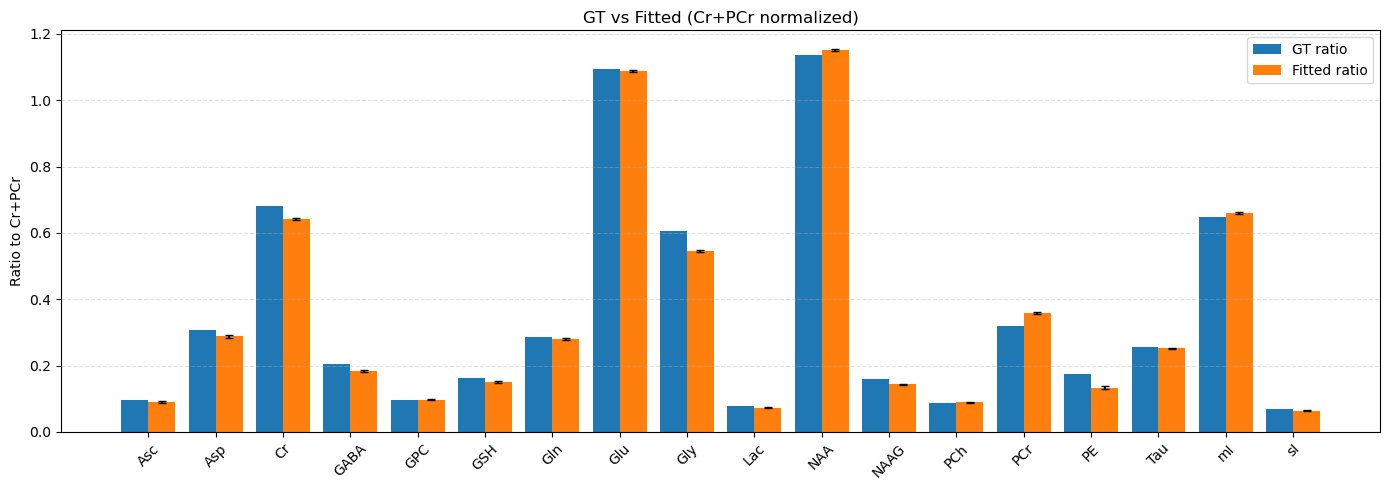

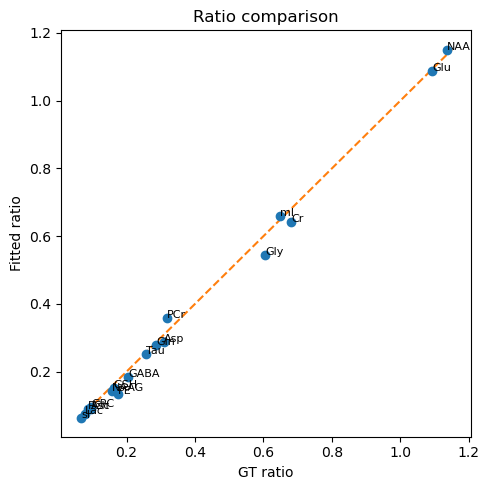

In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# FILE PATHS
# =====================================================
csv_path = "/home/arijitbhattacharya/Arijit/Arijit_MRS/Digital_MRS/Fitted_Withgt/summary.csv"
json_path = "/home/arijitbhattacharya/MRS-Digital-Phantom/outputs/simulation_20260213_3dgw/spectra/concentrations_1.json"

# =====================================================
# LOAD SUMMARY CSV
# =====================================================
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# we KNOW the columns
ratio_col = "/Cr+PCr"
crlb_col = "/Cr+PCr CRLB"

# =====================================================
# LOAD GT JSON
# =====================================================
with open(json_path) as f:
    gt = json.load(f)

gt_voxel = gt["voxel_weighted"]

# =====================================================
# COMPUTE GT Cr+PCr
# =====================================================
Cr_gt = gt_voxel.get("Cr", 0.0)
PCr_gt = gt_voxel.get("PCr", 0.0)

CrPCr_gt = Cr_gt + PCr_gt
print("\nGT Cr+PCr:", CrPCr_gt)

# =====================================================
# BUILD GT RATIOS
# =====================================================
gt_ratio = {}
for metab, val in gt_voxel.items():
    gt_ratio[metab] = val / CrPCr_gt

# =====================================================
# FITTED RATIOS
# =====================================================
fit_ratio = {}
fit_err = {}

for _, row in df.iterrows():
    metab = row["Metab"]
    fit_ratio[metab] = row[ratio_col]
    fit_err[metab] = row[crlb_col]

# =====================================================
# MATCH METABOLITES
# =====================================================
common = sorted(set(gt_ratio.keys()).intersection(fit_ratio.keys()))

gt_vals = np.array([gt_ratio[m] for m in common])
fit_vals = np.array([fit_ratio[m] for m in common])
fit_errs = np.array([fit_err[m] for m in common])
labels = np.array(common)

# remove NaNs
mask = ~np.isnan(gt_vals) & ~np.isnan(fit_vals)
gt_vals = gt_vals[mask]
fit_vals = fit_vals[mask]
fit_errs = fit_errs[mask]
labels = labels[mask]

print("Metabolites used:", labels)

# =====================================================
# STATS
# =====================================================
chi_each = ((fit_vals - gt_vals)**2) / (fit_errs**2 + 1e-12)
print("\nReduced chi2:", np.mean(chi_each))
print("Correlation:", np.corrcoef(gt_vals, fit_vals)[0,1])

# =====================================================
# BAR PLOT
# =====================================================
x = np.arange(len(labels))
width = 0.4

plt.figure(figsize=(14,5))

plt.bar(x - width/2, gt_vals, width, label="GT ratio")
plt.bar(x + width/2, fit_vals, width, yerr=fit_errs, capsize=3, label="Fitted ratio")

plt.xticks(x, labels, rotation=45)
plt.ylabel("Ratio to Cr+PCr")
plt.title("GT vs Fitted (Cr+PCr normalized)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# =====================================================
# SCATTER
# =====================================================
plt.figure(figsize=(5,5))
plt.errorbar(gt_vals, fit_vals, yerr=fit_errs, fmt='o')

mn = min(gt_vals.min(), fit_vals.min())
mx = max(gt_vals.max(), fit_vals.max())
plt.plot([mn, mx], [mn, mx], '--')

for i, lab in enumerate(labels):
    plt.text(gt_vals[i], fit_vals[i], lab, fontsize=8)

plt.xlabel("GT ratio")
plt.ylabel("Fitted ratio")
plt.title("Ratio comparison")
plt.tight_layout()
plt.show()
